In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import re
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================

train_file = "twitter_training.csv"
validation_file = "twitter_validation.csv"

# Dataset columns
columns = ["ID", "Entity", "Sentiment", "Tweet"]

train_df = pd.read_csv(
    train_file,
    header=None,
    names=columns
)

validation_df = pd.read_csv(
    validation_file,
    header=None,
    names=columns
)

print("Training Dataset Shape:", train_df.shape)
print("Validation Dataset Shape:", validation_df.shape)

print("\nFirst 5 Training Records:")
print(train_df.head())

Training Dataset Shape: (74682, 4)
Validation Dataset Shape: (1000, 4)

First 5 Training Records:
     ID       Entity Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                               Tweet  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [3]:
# ============================================================
# 3. BASIC DATA CLEANING
# ============================================================

# Remove missing tweets and sentiments
train_df = train_df.dropna(subset=["Tweet", "Sentiment"])
validation_df = validation_df.dropna(subset=["Tweet", "Sentiment"])

# Remove duplicate records
train_df = train_df.drop_duplicates()
validation_df = validation_df.drop_duplicates()

print("\nAfter Cleaning:")
print("Training Shape:", train_df.shape)
print("Validation Shape:", validation_df.shape)

print("\nMissing Values in Training Data:")
print(train_df.isnull().sum())


After Cleaning:
Training Shape: (71656, 4)
Validation Shape: (1000, 4)

Missing Values in Training Data:
ID           0
Entity       0
Sentiment    0
Tweet        0
dtype: int64


In [4]:
# ============================================================
# 4. CHECK SENTIMENT CLASSES
# ============================================================

print("\nSentiment Classes:")
print(train_df["Sentiment"].unique())

print("\nSentiment Distribution:")
print(train_df["Sentiment"].value_counts())


Sentiment Classes:
<ArrowStringArray>
['Positive', 'Neutral', 'Negative', 'Irrelevant']
Length: 4, dtype: str

Sentiment Distribution:
Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64


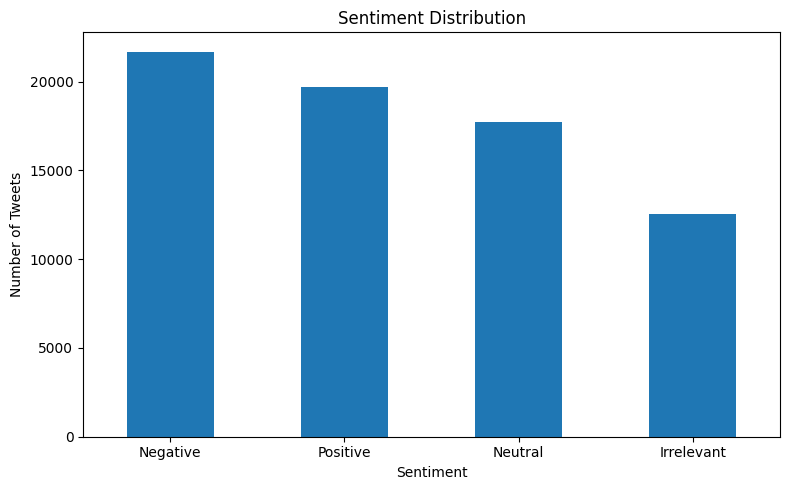

In [5]:
# ============================================================
# 5. SENTIMENT DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

train_df["Sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 6. TEXT PREPROCESSING
# ============================================================

def clean_text(text):
    """
    Clean tweet text for machine learning.
    """

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text



In [7]:
# Apply cleaning
train_df["Clean_Tweet"] = train_df["Tweet"].apply(clean_text)

validation_df["Clean_Tweet"] = validation_df["Tweet"].apply(clean_text)


# Show original and cleaned tweets
print("\nOriginal vs Cleaned Tweets:")
print(
    train_df[
        ["Tweet", "Clean_Tweet"]
    ].head(10)
)


Original vs Cleaned Tweets:
                                               Tweet  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   
5  im getting into borderlands and i can murder y...   
6  So I spent a few hours making something for fu...   
7  So I spent a couple of hours doing something f...   
8  So I spent a few hours doing something for fun...   
9  So I spent a few hours making something for fu...   

                                         Clean_Tweet  
0  im getting on borderlands and i will murder yo...  
1  i am coming to the borders and i will kill you...  
2  im getting on borderlands and i will kill you all  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
5  im getting into borde

In [8]:
# ============================================================
# 7. REMOVE EMPTY TWEETS
# ============================================================

train_df = train_df[
    train_df["Clean_Tweet"].str.len() > 0
]

validation_df = validation_df[
    validation_df["Clean_Tweet"].str.len() > 0
]

print("\nAfter Removing Empty Tweets:")
print("Training Shape:", train_df.shape)
print("Validation Shape:", validation_df.shape)




After Removing Empty Tweets:
Training Shape: (71172, 5)
Validation Shape: (1000, 5)


In [9]:
# ============================================================
# 8. PREPARE FEATURES AND TARGET
# ============================================================

X_train = train_df["Clean_Tweet"]
y_train = train_df["Sentiment"]

X_validation = validation_df["Clean_Tweet"]
y_validation = validation_df["Sentiment"]

print("\nTraining Samples:", len(X_train))
print("Validation Samples:", len(X_validation))


Training Samples: 71172
Validation Samples: 1000


In [10]:
# ============================================================
# 9. TF-IDF VECTORIZATION
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# Learn vocabulary from training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform validation data using same vocabulary
X_validation_tfidf = vectorizer.transform(X_validation)

print("\nTF-IDF Shapes:")
print("Training:", X_train_tfidf.shape)
print("Validation:", X_validation_tfidf.shape)


TF-IDF Shapes:
Training: (71172, 20000)
Validation: (1000, 20000)


In [11]:
# ============================================================
# 10. TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    max_iter=1000
)

print("\nTraining Logistic Regression Model...")

model.fit(
    X_train_tfidf,
    y_train
)

print("Model Training Completed!")


Training Logistic Regression Model...
Model Training Completed!


In [12]:
# ============================================================
# 11. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(X_validation_tfidf)

In [13]:
# ============================================================
# 12. MODEL ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_validation,
    y_pred
)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")


MODEL PERFORMANCE

Accuracy: 0.9160
Accuracy Percentage: 91.60%


In [14]:
# ============================================================
# 13. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_validation,
        y_pred
    )
)




Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.94      0.86      0.90       172
    Negative       0.89      0.97      0.93       266
     Neutral       0.95      0.90      0.92       285
    Positive       0.90      0.92      0.91       277

    accuracy                           0.92      1000
   macro avg       0.92      0.91      0.91      1000
weighted avg       0.92      0.92      0.92      1000



In [15]:

# ============================================================
# 14. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_validation,
    y_pred,
    labels=model.classes_
)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[148  10   2  12]
 [  1 257   5   3]
 [  3  12 257  13]
 [  6  10   7 254]]


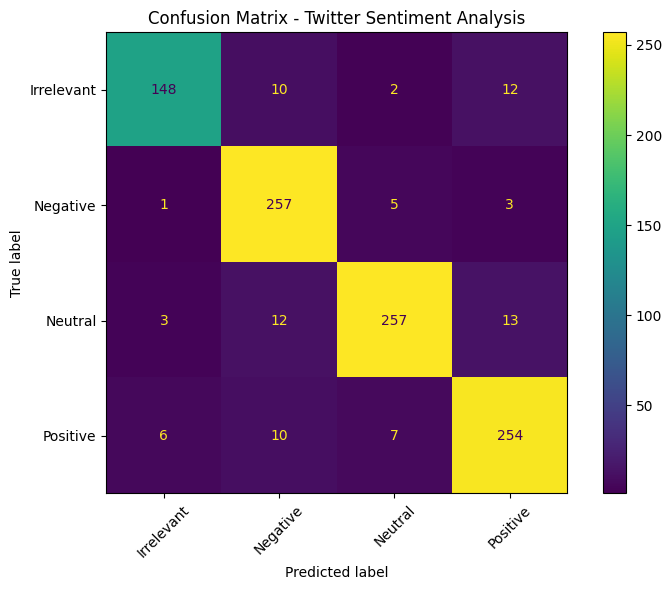

In [16]:
# ============================================================
# 15. CONFUSION MATRIX VISUALIZATION
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Confusion Matrix - Twitter Sentiment Analysis")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 16. CUSTOM SENTIMENT PREDICTION FUNCTION
# ============================================================

def predict_sentiment(text):

    # Clean input text
    cleaned_text = clean_text(text)

    # Convert text into TF-IDF
    text_vector = vectorizer.transform(
        [cleaned_text]
    )

    # Predict sentiment
    prediction = model.predict(
        text_vector
    )[0]

    # Get probabilities
    probabilities = model.predict_proba(
        text_vector
    )[0]

    # Highest probability
    confidence = probabilities.max()

    return prediction, confidence

In [18]:
# ============================================================
# 17. TEST CUSTOM TWEETS
# ============================================================

test_tweets = [
    "I absolutely love this product!",
    "This is the worst experience ever.",
    "The product is okay, nothing special.",
    "I am really happy with this game.",
    "I don't like this update at all."
]

print("\n==============================")
print("CUSTOM TWEET PREDICTIONS")
print("==============================")


for tweet in test_tweets:

    sentiment, confidence = predict_sentiment(tweet)

    print("\nTweet:", tweet)
    print("Predicted Sentiment:", sentiment)
    print(f"Confidence: {confidence:.2%}")


CUSTOM TWEET PREDICTIONS

Tweet: I absolutely love this product!
Predicted Sentiment: Positive
Confidence: 68.56%

Tweet: This is the worst experience ever.
Predicted Sentiment: Negative
Confidence: 85.82%

Tweet: The product is okay, nothing special.
Predicted Sentiment: Positive
Confidence: 49.98%

Tweet: I am really happy with this game.
Predicted Sentiment: Positive
Confidence: 68.50%

Tweet: I don't like this update at all.
Predicted Sentiment: Negative
Confidence: 76.21%


In [19]:
# ============================================================
# 18. SAVE PREDICTIONS
# ============================================================

results = validation_df[
    ["ID", "Entity", "Tweet", "Sentiment"]
].copy()

results["Predicted_Sentiment"] = y_pred

results.to_csv(
    "sentiment_predictions.csv",
    index=False
)

print("\nSaved: sentiment_predictions.csv")


Saved: sentiment_predictions.csv


In [20]:
# ============================================================
# 19. SAVE MODEL INFORMATION
# ============================================================

print("\n==============================")
print("PROJECT COMPLETED")
print("==============================")

print("Model: Logistic Regression")
print("Text Representation: TF-IDF")
print("Classes:", list(model.classes_))
print(f"Validation Accuracy: {accuracy * 100:.2f}%")


PROJECT COMPLETED
Model: Logistic Regression
Text Representation: TF-IDF
Classes: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Validation Accuracy: 91.60%


In [21]:
import joblib

joblib.dump(model, "sentiment_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
